<!--
  Licensed to the Apache Software Foundation (ASF) under one or more
  contributor license agreements.  See the NOTICE file distributed with
  this work for additional information regarding copyright ownership.
  The ASF licenses this file to You under the Apache License, Version 2.0
  (the "License"); you may not use this file except in compliance with
  the License.  You may obtain a copy of the License at

       http://www.apache.org/licenses/LICENSE-2.0

  Unless required by applicable law or agreed to in writing, software
  distributed under the License is distributed on an "AS IS" BASIS,
  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
  See the License for the specific language governing permissions and
  limitations under the License.
-->

# Hudi VECTOR + BLOB + Vector Search — DataFrame Variant

Same end state as the [SQL notebook](02_sql_vector_search.ipynb), but every
Hudi-touching step uses the **DataFrame API** — no `CREATE TABLE`, no
`INSERT INTO`, no Parquet staging. Mirrors the canonical pattern from
`TestVectorDataSource.testVectorRoundTrip` in the Hudi test suite.

The trick: declare a `StructType` upfront with
`ArrayType(FloatType, containsNull=False)` and `metadata={"hudi_type": "VECTOR(N)"}`
on the embedding column, hand it to `spark.createDataFrame(rows, schema)` —
Spark accepts the schema as authoritative — and write through with
`df.write.format("hudi").save(path)`.

A PyArrow → Parquet → `spark.read.parquet(...)` staging path would
introduce a Parquet round-trip that resets `containsNull` back to `True`
regardless of the originating schema, which then requires a separate SQL
`CREATE TABLE` path. Going schema-first via `createDataFrame` avoids the
round-trip entirely.

## 1. Toggles

In [1]:
# ===== EDIT THESE =====
BASE_FILE_FORMAT = "parquet"   # "parquet" or "lance"
N_SAMPLES        = 250
TOP_K            = 5
EMBEDDING_MODEL  = "mobilenetv3_small_100"

assert BASE_FILE_FORMAT in {"parquet", "lance"}

## 2. Pre-flight cleanup

In [ ]:
# Wipe leftover Hudi/Spark state from previous runs.
#
# Why: `DROP TABLE IF EXISTS` only removes the catalog entry — the data dir
# and `.hoodie/` timeline at LOCATION persist across runs. A re-run would
# see old commits alongside new ones, and for the blob_reader notebook the
# shared `/tmp/pets_blob_container.bin` is overwritten by every blob_mode
# run, which leaves stale tables pointing past EOF (→ file boundary errors
# during read). Cleaning up at the top makes every cell run idempotent.
import shutil
from pathlib import Path

for pattern in [
    "/tmp/hudi_*_pets",
    "/tmp/pets_blob_container.bin",
    "/tmp/staging_pets_*.parquet",
]:
    for p in Path("/").glob(pattern.lstrip("/")):
        if p.is_dir():
            shutil.rmtree(p, ignore_errors=True)
        elif p.is_file():
            p.unlink(missing_ok=True)

shutil.rmtree("spark-warehouse", ignore_errors=True)
print("✓ Wiped /tmp/hudi_*_pets, /tmp/pets_blob_container.bin, staging Parquet, spark-warehouse")

## 3. Pre-JVM env (driver heap)

In [3]:
# Pre-JVM env: must run BEFORE any `pyspark` import so the driver heap is
# set at JVM launch time. PySpark in local mode can't grow the heap later
# via SparkSession.config().
import os

DRIVER_MEMORY = "4g"   # bump to "8g" or "12g" for N >= 2000

os.environ.setdefault(
    "PYSPARK_SUBMIT_ARGS",
    f"--driver-memory {DRIVER_MEMORY} --conf spark.driver.maxResultSize=2g pyspark-shell",
)

'--driver-memory 4g --conf spark.driver.maxResultSize=2g pyspark-shell'

## 4. Imports

In [4]:
import io
from pathlib import Path

import numpy as np
import torch
import timm
from sklearn.preprocessing import normalize
from PIL import Image

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from torchvision.datasets import OxfordIIITPet

from pyspark.sql import DataFrame, Row, SparkSession
from pyspark.sql.types import (
    ArrayType, BinaryType, BooleanType, FloatType,
    IntegerType, LongType, StringType, StructField, StructType,
)
from IPython.display import Image as IPyImage, display


## 5. Configuration (derived from toggles)

In [5]:
CONFIG = {
    "dataset": "OxfordIIITPet",
    "table_path": f"/tmp/hudi_{BASE_FILE_FORMAT}_pets",
    "table_name": f"pets_{BASE_FILE_FORMAT}",
    "base_file_format": BASE_FILE_FORMAT,
    "n_samples": N_SAMPLES,
    "top_k": TOP_K,
    "embedding_model": EMBEDDING_MODEL,
    "output_dir": "./outputs",
    "panel_filename": f"hudi_{BASE_FILE_FORMAT}_results.png",
}

BLOB_REFERENCE_CAST = "struct<external_path:string,offset:bigint,length:bigint,managed:boolean>"

for k, v in CONFIG.items():
    print(f"  {k:20s}: {v}")

  dataset             : OxfordIIITPet
  table_path          : /tmp/hudi_parquet_pets
  table_name          : pets_parquet
  base_file_format    : parquet
  n_samples           : 250
  top_k               : 5
  embedding_model     : mobilenetv3_small_100
  output_dir          : ./outputs
  panel_filename      : hudi_parquet_results.png


## 6. Resolve Hudi (and optionally Lance) jars

In [6]:
import sys
from pathlib import Path

def default_hudi_bundle_jar() -> str:
    # Defaults to the Apache 1.2.0-rc1 staging jar in ~/Downloads/. Grab it with:
    #   curl -L -o ~/Downloads/hudi-spark3.5-bundle_2.12-1.2.0-rc1.jar \
    #     https://repository.apache.org/content/repositories/orgapachehudi-1176/org/apache/hudi/hudi-spark3.5-bundle_2.12/1.2.0-rc1/hudi-spark3.5-bundle_2.12-1.2.0-rc1.jar
    # Override via HUDI_BUNDLE_JAR env var to point at a locally built bundle.
    return str(Path.home() / "Downloads" / "hudi-spark3.5-bundle_2.12-1.2.0-rc1.jar")

def default_lance_bundle_jar() -> str:
    # Defaults to the Maven Central Lance 0.4.0 jar in ~/Downloads/. Grab it with:
    #   curl -L -o ~/Downloads/lance-spark-bundle-3.5_2.12-0.4.0.jar \
    #     https://repo1.maven.org/maven2/com/lancedb/lance-spark-bundle-3.5_2.12/0.4.0/lance-spark-bundle-3.5_2.12-0.4.0.jar
    return str(Path.home() / "Downloads" / "lance-spark-bundle-3.5_2.12-0.4.0.jar")

def resolve_jars(base_file_format: str) -> str:
    hudi_jar = os.getenv("HUDI_BUNDLE_JAR", default_hudi_bundle_jar())
    if not Path(hudi_jar).is_file():
        sys.exit(
            f"ERROR: HUDI_BUNDLE_JAR does not exist at {hudi_jar}\n"
            "Download the Apache 1.2.0-rc1 staging jar to ~/Downloads/ "
            "or set HUDI_BUNDLE_JAR=/abs/path/to/locally-built.jar "
            "before launching jupyter."
        )
    if base_file_format != "lance":
        return hudi_jar
    lance_jar = os.getenv("LANCE_BUNDLE_JAR", default_lance_bundle_jar())
    if not Path(lance_jar).is_file():
        sys.exit(
            f"ERROR: LANCE_BUNDLE_JAR does not exist at {lance_jar}\n"
            "Download lance-spark-bundle-3.5_2.12-0.4.0.jar from Maven Central "
            "to ~/Downloads/ or set LANCE_BUNDLE_JAR=/abs/path/to/jar "
            "before launching jupyter."
        )
    return f"{hudi_jar},{lance_jar}"

## 7. Spark session

In [7]:
jars = resolve_jars(CONFIG["base_file_format"])

spark = (
    SparkSession.builder
    .appName("Hudi-Vector-Blob-Demo")
    .config("spark.jars", jars)
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.sql.extensions", "org.apache.spark.sql.hudi.HoodieSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.hudi.catalog.HoodieCatalog")
    .config("spark.sql.session.timeZone", "UTC")
    .config("hoodie.read.blob.inline.mode", "CONTENT")
    .config("spark.default.parallelism", "2")
    .config("spark.sql.shuffle.partitions", "2")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("✓ Spark session ready")

26/04/27 19:21:43 WARN Utils: Your hostname, mac.lan resolves to a loopback address: 127.0.0.1; using 192.168.86.21 instead (on interface en0)
26/04/27 19:21:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/04/27 19:21:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


✓ Spark session ready


## 8. Load Oxford-IIIT Pet

In [8]:
print(f"Loading dataset: Oxford-IIIT Pet ({CONFIG['n_samples']} samples)...")
root = os.path.expanduser("~/.cache/torchvision")
ds = OxfordIIITPet(root=root, split="trainval", download=True)
class_names = ds.classes

rng = np.random.default_rng()
n = min(CONFIG["n_samples"], len(ds))
indices = rng.choice(len(ds), size=n, replace=False)

data = []
for idx in indices:
    img, label = ds[int(idx)]
    img = img.convert("RGB")
    bio = io.BytesIO()
    img.save(bio, format="PNG")
    img_bytes = bio.getvalue()
    w, h = img.size
    category = class_names[label] if isinstance(class_names, list) else str(label)
    data.append({
        "image_id": f"pets_{int(idx):06d}",
        "category": category,
        "category_sanitized": category.replace("/", "_"),
        "label": int(label),
        "description": f"{category} from Oxford-IIIT Pet",
        "image_bytes_raw": img_bytes,
        "width": int(w),
        "height": int(h),
    })

print(f"✓ Loaded {len(data)} images")

Loading dataset: Oxford-IIIT Pet (250 samples)...
✓ Loaded 250 images


## 9. Embedding model (timm) + generate embeddings

In [9]:
print(f"Loading embedding model: {CONFIG['embedding_model']}...")
model = timm.create_model(CONFIG["embedding_model"], pretrained=True, num_classes=0)
model.eval()
data_config = timm.data.resolve_model_data_config(model)
transform = timm.data.create_transform(**data_config, is_training=False)
print("✓ Model loaded")

images = [transform(Image.open(io.BytesIO(d["image_bytes_raw"])).convert("RGB"))
          for d in data]
batch = torch.stack(images)
with torch.no_grad():
    feats = model(batch).detach().cpu().numpy()
feats = normalize(feats)
for i, d in enumerate(data):
    d["embedding"] = feats[i].tolist()
embedding_dim = int(feats.shape[1])
print(f"✓ Generated embeddings (dimension: {embedding_dim})")

Loading embedding model: mobilenetv3_small_100...
✓ Model loaded
✓ Generated embeddings (dimension: 1024)


## 10. Declare the target StructType (with VECTOR + BLOB annotations)

This is the whole story for "make Hudi accept this DataFrame":

- `embedding` is `ArrayType(FloatType, containsNull=False)` with
  `metadata = {"hudi_type": "VECTOR(N)"}` — the two annotations Hudi's
  VECTOR validator looks for.
- `image_bytes` is the BLOB struct shape with `metadata = {"hudi_type": "BLOB"}`.

`spark.createDataFrame(rows, schema)` (Step 12) accepts this schema as
authoritative — no inference, no Parquet round-trip, no implicit analyzer
cast applied. This mirrors `TestVectorDataSource.testVectorRoundTrip`.

In [10]:
BLOB_STRUCT_TYPE = StructType([
    StructField("type", StringType(), nullable=False),
    StructField("data", BinaryType(), nullable=True),
    StructField("reference", StructType([
        StructField("external_path", StringType(), nullable=True),
        StructField("offset", LongType(), nullable=True),
        StructField("length", LongType(), nullable=True),
        StructField("managed", BooleanType(), nullable=True),
    ]), nullable=True),
])

target_schema = StructType([
    StructField("image_id", StringType(), nullable=False),
    StructField("category", StringType(), nullable=False),
    StructField("category_sanitized", StringType(), nullable=False),
    StructField("label", IntegerType(), nullable=False),
    StructField("description", StringType(), nullable=True),
    StructField("image_bytes", BLOB_STRUCT_TYPE, nullable=True,
                metadata={"hudi_type": "BLOB"}),
    StructField("width", IntegerType(), nullable=False),
    StructField("height", IntegerType(), nullable=False),
    StructField("embedding",
                ArrayType(FloatType(), containsNull=False),
                nullable=False,
                metadata={"hudi_type": f"VECTOR({embedding_dim})"}),
])

print(target_schema.simpleString())


struct<image_id:string,category:string,category_sanitized:string,label:int,description:string,image_bytes:struct<type:string,data:binary,reference:struct<external_path:string,offset:bigint,length:bigint,managed:boolean>>,width:int,height:int,embedding:array<float>>


## 11. Build positional `Row` tuples from the dataset

`spark.createDataFrame(rows, schema)` accepts an iterable of `Row` (or
plain tuples) where field order matches `schema`. The nested `image_bytes`
field becomes a nested `Row("INLINE", <bytes>, None)` — INLINE BLOB with
no external reference.


In [11]:
rows = [
    Row(
        d["image_id"],
        d["category"],
        d["category_sanitized"],
        int(d["label"]),
        d.get("description"),
        Row("INLINE", d["image_bytes_raw"], None),
        int(d["width"]),
        int(d["height"]),
        [float(v) for v in d["embedding"]],
    )
    for d in data
]
print(f"Built {len(rows)} rows")


Built 250 rows


## 12. `spark.createDataFrame(rows, schema)` — schema is authoritative

The key call. With explicit `schema` provided, Spark does NOT re-infer
the column types — `containsNull = False` survives, the
`hudi_type` metadata survives, and the resulting DataFrame is ready to
hand to `df.write`.


In [12]:
df = spark.createDataFrame(rows, target_schema)
df.printSchema()


root
 |-- image_id: string (nullable = false)
 |-- category: string (nullable = false)
 |-- category_sanitized: string (nullable = false)
 |-- label: integer (nullable = false)
 |-- description: string (nullable = true)
 |-- image_bytes: struct (nullable = true)
 |    |-- type: string (nullable = false)
 |    |-- data: binary (nullable = true)
 |    |-- reference: struct (nullable = true)
 |    |    |-- external_path: string (nullable = true)
 |    |    |-- offset: long (nullable = true)
 |    |    |-- length: long (nullable = true)
 |    |    |-- managed: boolean (nullable = true)
 |-- width: integer (nullable = false)
 |-- height: integer (nullable = false)
 |-- embedding: array (nullable = false)
 |    |-- element: float (containsNull = false)



## 13. Write to Hudi — `df.write.format("hudi").save(path)`

Pure DataFrame V1 write. No `CREATE TABLE`, no `INSERT INTO`, no temp
view. Hudi sees a valid VECTOR + BLOB schema, creates the table on
first write (mode="overwrite"), and commits.

The two Hudi-specific options worth flagging:
- `hoodie.table.base.file.format` — `parquet` or `lance`
- `hoodie.write.record.merge.custom.implementation.classes` — required
  for Lance writes (flips the writer factory from AVRO to SPARK).


In [13]:
(
    df.write.format("hudi")
    .option("hoodie.table.name", CONFIG["table_name"])
    .option("hoodie.datasource.write.recordkey.field", "image_id")
    .option("hoodie.datasource.write.precombine.field", "image_id")
    .option("hoodie.datasource.write.partitionpath.field", "category_sanitized")
    .option("hoodie.datasource.write.table.type", "COPY_ON_WRITE")
    .option("hoodie.table.base.file.format", CONFIG["base_file_format"])
    .option(
        "hoodie.write.record.merge.custom.implementation.classes",
        "org.apache.hudi.DefaultSparkRecordMerger",
    )
    .mode("overwrite")
    .save(CONFIG["table_path"])
)

count = spark.read.format("hudi").load(CONFIG["table_path"]).count()
print(f"✓ Wrote {count} records to {CONFIG['table_path']}")


# WARNING: Unable to get Instrumentation. Dynamic Attach failed. You may add this JAR as -javaagent manually, or supply -Djdk.attach.allowAttachSelf
# WARNING: Unable to attach Serviceability Agent. Unable to attach even with module exceptions: [org.apache.hudi.org.openjdk.jol.vm.sa.SASupportException: Sense failed., org.apache.hudi.org.openjdk.jol.vm.sa.SASupportException: Sense failed., org.apache.hudi.org.openjdk.jol.vm.sa.SASupportException: Sense failed.]
✓ Wrote 250 records to /tmp/hudi_parquet_pets


## 14. Sample rows

In [14]:
df.select("image_id", "category", "description").show(5, truncate=False)

+-----------+-----------------+--------------------------------------+
|image_id   |category         |description                           |
+-----------+-----------------+--------------------------------------+
|pets_000006|Abyssinian       |Abyssinian from Oxford-IIIT Pet       |
|pets_001641|Siamese          |Siamese from Oxford-IIIT Pet          |
|pets_001859|Abyssinian       |Abyssinian from Oxford-IIIT Pet       |
|pets_001101|Newfoundland     |Newfoundland from Oxford-IIIT Pet     |
|pets_001825|Yorkshire Terrier|Yorkshire Terrier from Oxford-IIIT Pet|
+-----------+-----------------+--------------------------------------+
only showing top 5 rows



## 15. Vector search — `hudi_vector_search` wrapped as a DataFrame helper

`hudi_vector_search` is a SQL TVF — there's no native DataFrame builder
for it. The helper below wraps the call so the rest of the demo speaks
DataFrame: chain `.orderBy(...)`, `.select(...)`, `.collect()` on the
result like any other DataFrame.


In [15]:
def hudi_vector_search_df(
    spark: SparkSession,
    table_path: str,
    column: str,
    query_vector,
    k: int,
    metric: str = "cosine",
) -> DataFrame:
    array_literal = "ARRAY(" + ", ".join(f"{float(v)}" for v in query_vector) + ")"
    return spark.sql(
        f"""
        SELECT image_id, category, image_bytes, _hudi_distance
        FROM hudi_vector_search(
            '{table_path}',
            '{column}',
            {array_literal},
            {k},
            '{metric}'
        )
        """
    )


query_idx = np.random.randint(len(data))
query_item = data[query_idx]
print(f"Query: {query_item['image_id']} ({query_item['category']})")

rows = (
    hudi_vector_search_df(
        spark,
        CONFIG["table_path"],
        "embedding",
        query_item["embedding"],
        k=CONFIG["top_k"] + 1,
        metric="cosine",
    )
    .orderBy("_hudi_distance")
    .collect()
)

results = []
for row in rows:
    distance = float(row["_hudi_distance"])
    if distance < 0.001:
        continue
    if len(results) >= CONFIG["top_k"]:
        break
    blob = row["image_bytes"]
    inline_bytes = blob["data"] if blob is not None else None
    results.append({
        "image_id": row["image_id"],
        "category": row["category"],
        "image_bytes": bytes(inline_bytes) if inline_bytes is not None else b"",
        "similarity": 1.0 - distance,
    })

print(f"\n✓ Top {len(results)} matches:")
for i, r in enumerate(results, 1):
    print(f"  {i}. {r['image_id']:18s} {r['category']:30s} sim={r['similarity']:.3f}")


Query: pets_000076 (American Bulldog)

✓ Top 5 matches:
  1. pets_001946        American Pit Bull Terrier      sim=0.527
  2. pets_000512        Chihuahua                      sim=0.519
  3. pets_001744        Staffordshire Bull Terrier     sim=0.457
  4. pets_000077        American Bulldog               sim=0.457
  5. pets_001937        American Bulldog               sim=0.448


## 16. Visualize — query + top-K panel

✓ Panel saved: outputs/hudi_parquet_results.png


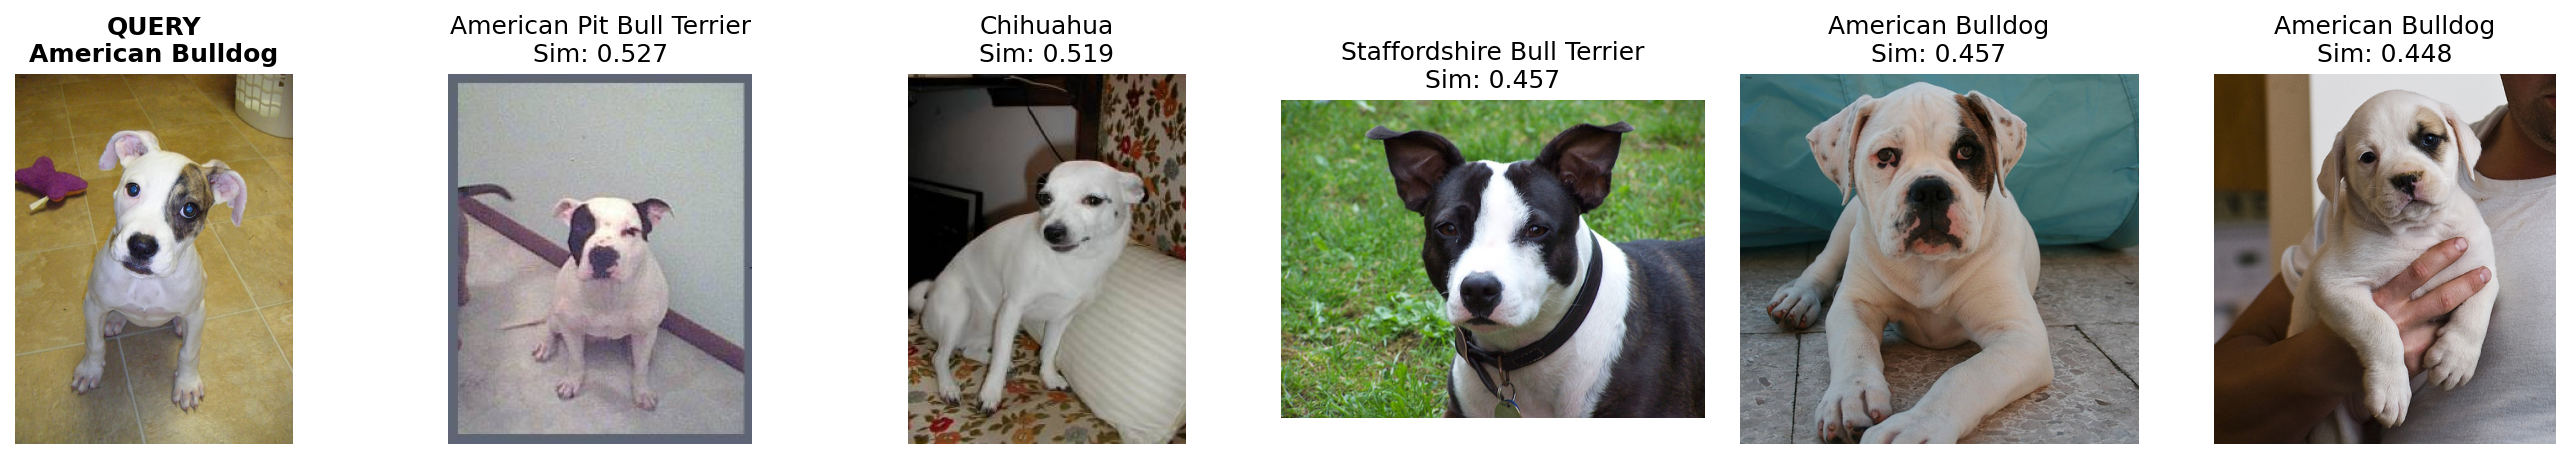

In [16]:
out_dir = Path(CONFIG["output_dir"])
out_dir.mkdir(parents=True, exist_ok=True)

n_results = len(results)
fig, axes = plt.subplots(1, n_results + 1, figsize=(3 * (n_results + 1), 3.2))
query_img = Image.open(io.BytesIO(query_item["image_bytes_raw"])).convert("RGB")
axes[0].imshow(query_img)
axes[0].set_title(f"QUERY\n{query_item['category']}", fontweight="bold")
axes[0].axis("off")
for i, r in enumerate(results):
    img = Image.open(io.BytesIO(r["image_bytes"])).convert("RGB")
    axes[i + 1].imshow(img)
    axes[i + 1].set_title(f"{r['category']}\nSim: {r['similarity']:.3f}")
    axes[i + 1].axis("off")
plt.tight_layout()
panel_path = out_dir / CONFIG["panel_filename"]
plt.savefig(str(panel_path), dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"✓ Panel saved: {panel_path}")
display(IPyImage(filename=str(panel_path)))

## 17. Stop Spark (optional)

In [17]:
spark.stop()
print("✓ Spark stopped")

✓ Spark stopped
